<a href="https://colab.research.google.com/github/CharlyUP-300/Recorrido-BFS-DFS/blob/main/recorridoBFS_DFS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

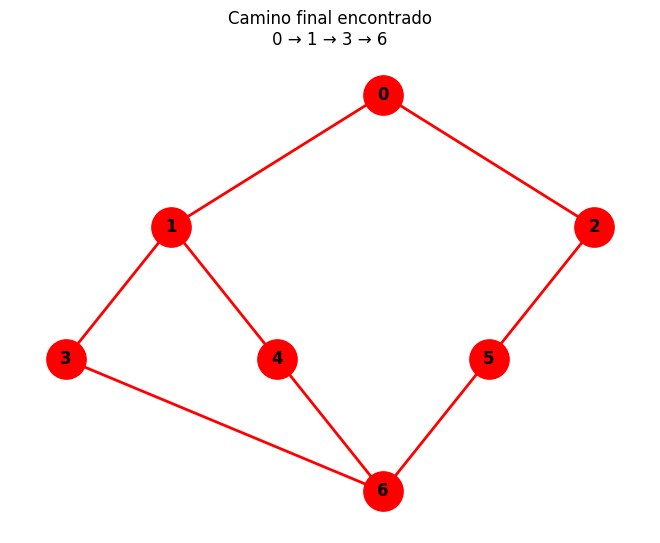

In [ ]:
!pip install networkx matplotlib -q

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
from collections import deque
from IPython.display import clear_output

# -------- Grafo --------
G = nx.Graph()
G.add_edges_from([(0,1),(0,2),(1,3),(1,4),(2,5),(2,6),(4,7),(6,7)])

pos = {
    0:(0,3), 1:(-1.5,2), 2:(1.5,2),
    3:(-2.5,1), 4:(-0.5,1), 5:(0.5,1), 6:(2.5,1), 7:(1,0)
}

# -------- Algoritmos --------
def bfs(graph, start):
    visited, tree_edges, queue, parent = [], [], deque([start]), {start: None}
    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.append(node)
            if parent[node] is not None:
                tree_edges.append((parent[node], node))
            for n in graph.neighbors(node):
                if n not in parent:
                    parent[n] = node
                    queue.append(n)
    return visited, tree_edges

def dfs(graph, start):
    visited, tree_edges, stack, parent = [], [], [start], {start: None}
    while stack:
        node = stack.pop()
        if node not in visited:
            visited.append(node)
            if parent[node] is not None:
                tree_edges.append((parent[node], node))
            for n in reversed(list(graph.neighbors(node))):
                if n not in parent:
                    parent[n] = node
                    stack.append(n)
    return visited, tree_edges

# -------- Animación --------
def animate(visited, tree_edges, algo):
    accent = "#E63946" if algo == "DFS" else "#457B9D"
    label  = "profundidad" if algo == "DFS" else "niveles"

    for i in range(len(visited)):
        clear_output(wait=True)

        fig, (ax_graph, ax_bar) = plt.subplots(
            1, 2, figsize=(12, 5),
            gridspec_kw={"width_ratios": [2, 1]}
        )
        fig.patch.set_facecolor("#F8F8F8")

        # ── Grafo ──
        ax_graph.set_facecolor("#F8F8F8")

        seen      = set(visited[:i+1])
        current   = visited[i]
        done_edges= set(map(tuple, tree_edges[:i]))

        node_colors = []
        node_sizes  = []
        for n in G.nodes():
            if n == current:
                node_colors.append(accent)
                node_sizes.append(900)
            elif n in seen:
                node_colors.append("#D0D0D0")
                node_sizes.append(700)
            else:
                node_colors.append("#FFFFFF")
                node_sizes.append(700)

        edge_colors = []
        edge_widths = []
        for e in G.edges():
            if tuple(e) in done_edges or (e[1], e[0]) in done_edges:
                edge_colors.append(accent)
                edge_widths.append(2.5)
            else:
                edge_colors.append("#CCCCCC")
                edge_widths.append(1)

        nx.draw(G, pos, ax=ax_graph,
                with_labels=True,
                node_color=node_colors,
                edge_color=edge_colors,
                node_size=node_sizes,
                width=edge_widths,
                font_size=11,
                font_weight="bold",
                font_color="#222222")

        ax_graph.set_title(
            f"{algo}  ·  nodo actual → {current}",
            fontsize=13, fontweight="bold",
            color="#222", pad=12, loc="left"
        )

        # ── Barra lateral: historial ──
        ax_bar.set_facecolor("#F8F8F8")
        ax_bar.set_xlim(0, 1)
        ax_bar.set_ylim(-0.5, len(G.nodes()) - 0.5)
        ax_bar.axis("off")

        ax_bar.text(0.5, len(G.nodes()) - 0.1,
                    "orden de visita",
                    ha="center", va="bottom",
                    fontsize=10, color="#AAAAAA",
                    fontfamily="monospace")

        for j, n in enumerate(visited[:i+1]):
            color = accent if j == i else "#D0D0D0"
            ax_bar.add_patch(
                mpatches.FancyBboxPatch(
                    (0.15, j - 0.35), 0.7, 0.6,
                    boxstyle="round,pad=0.05",
                    facecolor=color, edgecolor="none"
                )
            )
            ax_bar.text(0.5, j + 0.02, str(n),
                        ha="center", va="center",
                        fontsize=12, fontweight="bold",
                        color="white" if color == accent else "#888888",
                        fontfamily="monospace")

        # Progreso
        prog = (i + 1) / len(G.nodes())
        ax_bar.add_patch(mpatches.FancyBboxPatch(
            (0.1, -0.45), 0.8 * prog, 0.25,
            boxstyle="round,pad=0.02",
            facecolor=accent, edgecolor="none", alpha=0.3
        ))

        plt.tight_layout(pad=2)
        plt.show()
        time.sleep(1)

    # ── Pantalla final ──
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor("#F8F8F8")
    ax.set_facecolor("#F8F8F8")

    nx.draw(G, pos, ax=ax,
            with_labels=True,
            node_color=[accent] * len(G.nodes()),
            edge_color=[accent if (tuple(e) in set(map(tuple,tree_edges)) or (e[1],e[0]) in set(map(tuple,tree_edges))) else "#CCCCCC" for e in G.edges()],
            node_size=750, width=2.5,
            font_size=11, font_weight="bold", font_color="white")

    path_str = "  →  ".join(str(n) for n in visited)
    ax.set_title(
        f"{algo} completo  ·  recorrido por {label}\n{path_str}",
        fontsize=12, color="#222", pad=14, loc="center", linespacing=1.8
    )
    plt.tight_layout()
    plt.show()

# -------- Correr --------
print("━" * 40)
print("  BFS  —  búsqueda por niveles")
print("━" * 40)
bfs_nodes, bfs_edges = bfs(G, 0)
print("inicia en 3 s  ·  " + "  →  ".join(map(str, bfs_nodes)))
time.sleep(3)
animate(bfs_nodes, bfs_edges, "BFS")

time.sleep(4)

print("━" * 40)
print("  DFS  —  búsqueda en profundidad")
print("━" * 40)
dfs_nodes, dfs_edges = dfs(G, 0)
print("inicia en 3 s  ·  " + "  →  ".join(map(str, dfs_nodes)))
time.sleep(3)
animate(dfs_nodes, dfs_edges, "DFS")